In [8]:
import pandas as pd

In [9]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"

In [10]:
data = pd.read_csv(url, header=None)
data.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

In [11]:
X = data.drop('class', axis=1)
Y = data['class'].astype('category').cat.codes

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42, train_size=0.7)

In [2]:
pip install -q xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import xgboost as xgb

In [14]:
model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, use_label_encoder=False, eval_metric='mlogloss')

In [15]:
model.fit(X_train, Y_train)

c:\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:54:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test, y_pred))

1.0


In [18]:
import matplotlib.pyplot as plt

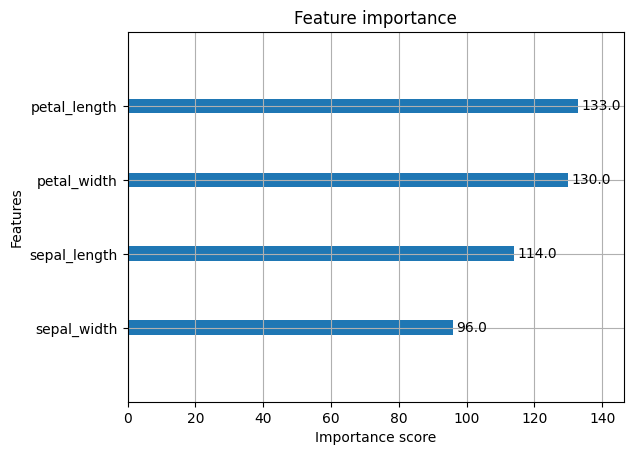

In [19]:
xgb.plot_importance(model)
plt.show()